In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('iot_sensor_data.csv')
df

,Timestamp,Device_ID,Temperature,Humidity,Pressure
0,2024-01-01 10:00,D1,22.5,45,1012
1,2024-01-01 10:10,D1,23.1,47,1013
2,2024-01-01 10:20,D1,35.0,90,990
3,2024-01-01 10:30,D1,23.0,46,1012
4,2024-01-01 10:40,D1,22.8,44,1011
5,2024-01-01 10:50,D1,40.0,95,980


In [3]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df

,Timestamp,Device_ID,Temperature,Humidity,Pressure
0,2024-01-01 10:00:00,D1,22.5,45,1012
1,2024-01-01 10:10:00,D1,23.1,47,1013
2,2024-01-01 10:20:00,D1,35.0,90,990
3,2024-01-01 10:30:00,D1,23.0,46,1012
4,2024-01-01 10:40:00,D1,22.8,44,1011
5,2024-01-01 10:50:00,D1,40.0,95,980


In [4]:
temp = df['Temperature'].values
mean_temp = np.mean(temp)
std_temp = np.std(temp)
print("\nMean Temperature: ", mean_temp)
print("Standard Deviation of Temperature: ", std_temp)


Mean Temperature:  27.73333333333333
Standard Deviation of Temperature:  7.057777427931701


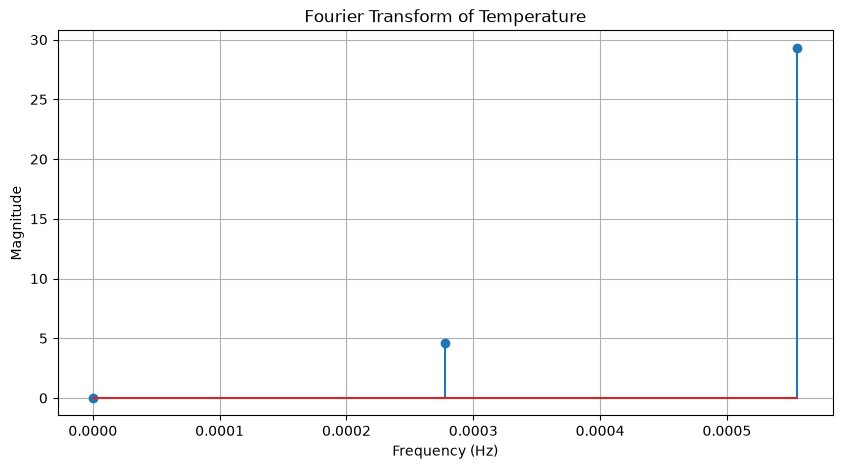

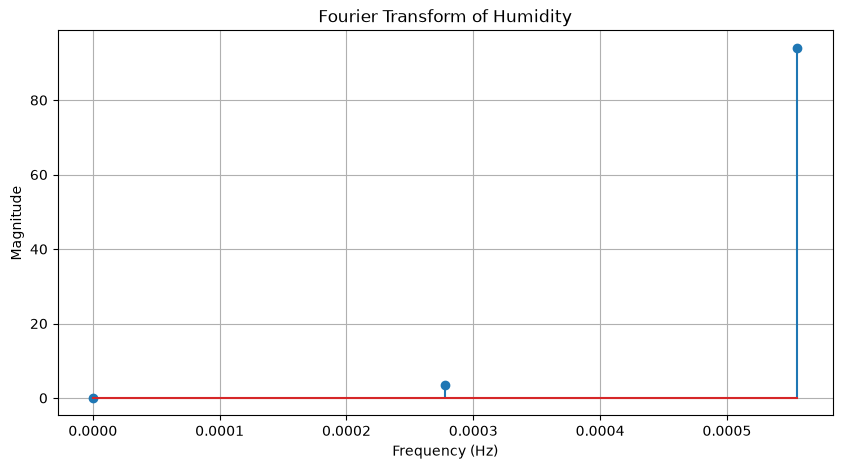

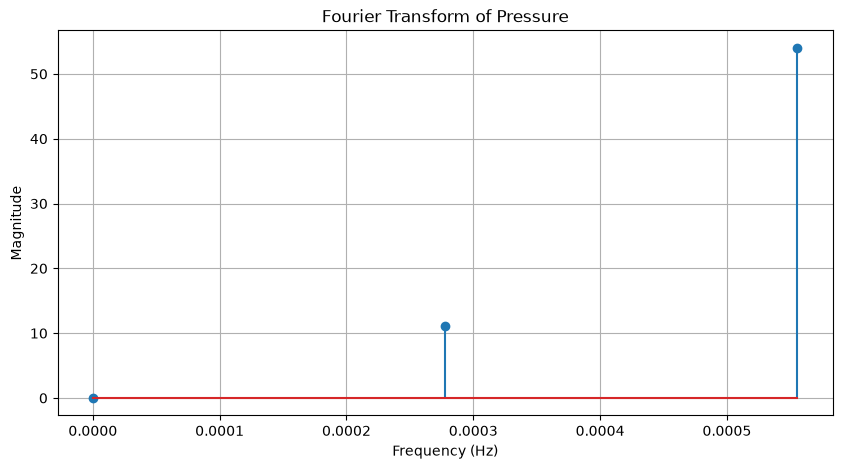

In [6]:
sampling_interval = 10 * 60  # seconds

# Signals to analyze
signals = ["Temperature", "Humidity", "Pressure"]

for signal in signals:

    # Get signal data
    data = df[signal].values

    # Remove mean/DC component
    data_centered = data - np.mean(data)

    # Apply FFT
    fft_result = np.fft.fft(data_centered)

    # Calculate frequencies
    frequencies = np.fft.fftfreq(
        len(data_centered),
        d=sampling_interval
    )

    # Only use positive frequencies
    positive = frequencies >= 0

    frequencies = frequencies[positive]
    magnitude = np.abs(fft_result[positive])

    # Plot
    plt.figure(figsize=(10, 5))

    plt.stem(frequencies, magnitude)

    plt.title(f"Fourier Transform of {signal}")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.grid(True)
    plt.show()

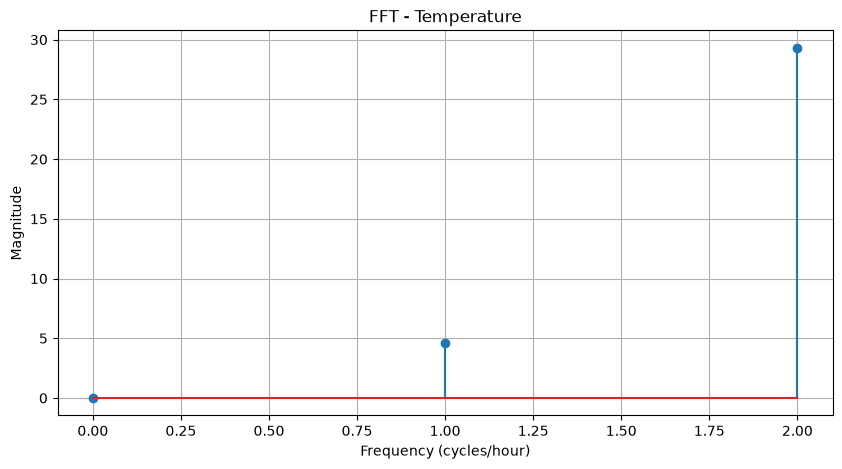

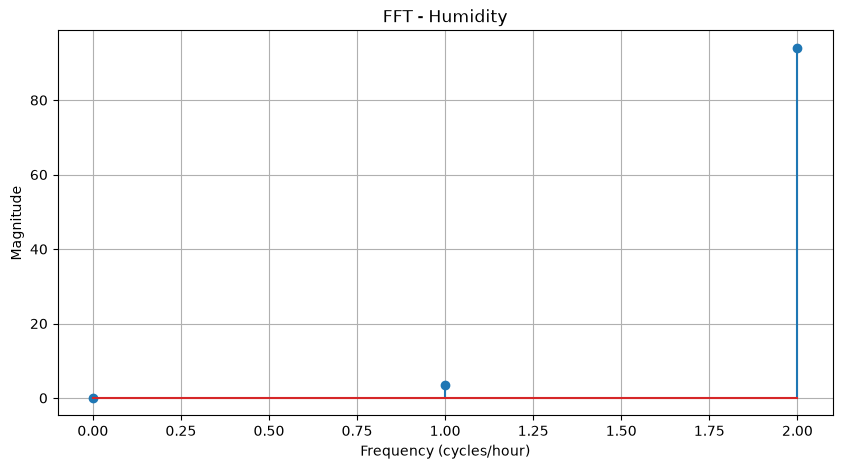

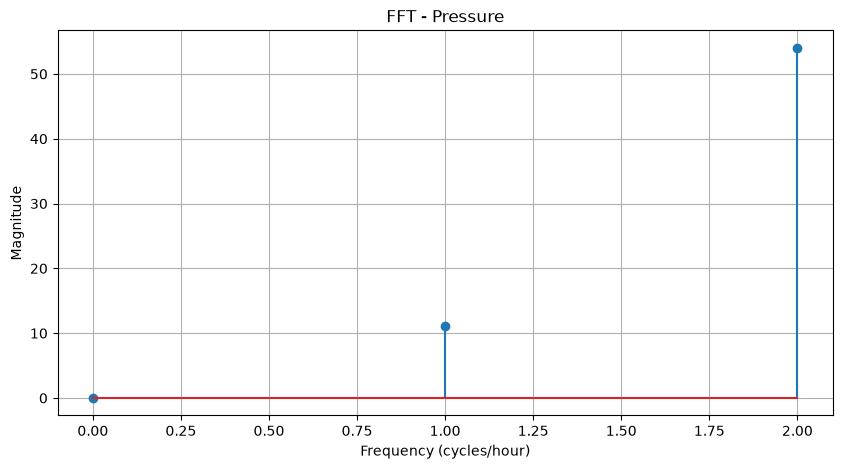

In [7]:
signals = ["Temperature", "Humidity", "Pressure"]

# Sampling time = 10 minutes = 1/6 hour
sampling_time = 1 / 6

for signal in signals:

    data = df[signal].values

    # Remove average value
    data = data - np.mean(data)

    # FFT
    fft_result = np.fft.fft(data)

    # Frequencies
    frequencies = np.fft.fftfreq(len(data), d=sampling_time)

    # Positive frequencies
    positive = frequencies >= 0

    frequencies = frequencies[positive]
    magnitude = np.abs(fft_result[positive])

    plt.figure(figsize=(10, 5))
    plt.stem(frequencies, magnitude)

    plt.title(f"FFT - {signal}")
    plt.xlabel("Frequency (cycles/hour)")
    plt.ylabel("Magnitude")
    plt.grid(True)

    plt.show()